# Part 5 — Imbalance Handling

In the previous classification stage, the models achieved strong overall accuracy but struggled to correctly identify employees who left the organisation.

This stage focuses on improving attrition detection using imbalance handling techniques such as:
- class weighting,
- threshold tuning,
- and SMOTE.

The goal is to improve recall and F1 score for the attrition class while maintaining reasonable precision and business usability.

## Why Class Imbalance Matters

The dataset is imbalanced because most employees stayed while only a smaller percentage left.

This creates a problem for machine learning models because they may learn to predict the majority class more often in order to maximise accuracy.

For employee attrition:
- False negatives are costly because employees at risk of leaving are missed.
- False positives also matter because HR resources may be wasted on employees who are not truly at risk.

Because of this, metrics such as:
- recall,
- precision,
- F1 score,
- and ROC-AUC

are more useful than accuracy alone.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    precision_recall_curve,
    classification_report
)

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Imbalance handling
from imblearn.over_sampling import SMOTE

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1. Load Processed Dataset

The processed dataset from the earlier stages is loaded here.

This dataset already includes:
- cleaned variables,
- engineered features,
- encoded variables,
- and scaled features.

In [5]:
df = pd.read_csv("../data/processed/hr_attrition_feature_engineered.csv")

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,MaritalStatus_Single,AgeGroup_EarlyCareer,AgeGroup_MidCareer,AgeGroup_Senior,IncomeBand_Medium,IncomeBand_High,IncomeBand_VeryHigh,YearsAtCompanyGroup_EarlyTenure,YearsAtCompanyGroup_Established,YearsAtCompanyGroup_LongTenure
0,0.446350,1,0.742527,-1.010909,-0.891688,-1.701283,-0.660531,-1.224745,1.383138,0.379672,...,1.458650,-0.837490,1.463224,-0.477567,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
1,1.322365,0,-1.297775,-0.147150,-1.868426,-1.699621,0.254625,0.816497,-0.240677,-1.026167,...,-0.685565,-0.837490,-0.683422,2.093947,-0.575779,1.733623,-0.577874,-0.647239,1.510381,-0.448308
2,0.008343,1,1.414363,-0.887515,-0.891688,-1.696298,1.169781,0.816497,1.284725,-1.026167,...,1.458650,-0.837490,1.463224,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308
3,-0.429664,0,1.461466,-0.764121,1.061787,-1.694636,1.169781,-1.224745,-0.486709,0.379672,...,-0.685565,1.194045,-0.683422,-0.477567,-0.575779,-0.576827,-0.577874,-0.647239,1.510381,-0.448308
4,-1.086676,0,-0.524295,-0.887515,-1.868426,-1.691313,-1.575686,0.816497,-1.274014,0.379672,...,-0.685565,1.194045,-0.683422,-0.477567,1.736777,-0.576827,-0.577874,-0.647239,-0.662085,-0.448308


## 2. Define Features and Target

The target variable is Attrition:
- 1 = employee left
- 0 = employee stayed

In [6]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1470, 57)
Target shape: (1470,)


## 3. Train/Test Split

A stratified split is used to preserve the original class proportions.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 4. Baseline Model

This baseline model provides the reference point before imbalance handling.

In [8]:
baseline_model = LogisticRegression(max_iter=1000)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_results = {
    "Accuracy": accuracy_score(y_test, baseline_pred),
    "Precision": precision_score(y_test, baseline_pred),
    "Recall": recall_score(y_test, baseline_pred),
    "F1": f1_score(y_test, baseline_pred),
    "ROC-AUC": roc_auc_score(y_test, baseline_proba)
}

pd.DataFrame([baseline_results])

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.867347,0.666667,0.340426,0.450704,0.836851


### Baseline Findings

The baseline Logistic Regression model achieved strong overall accuracy (86.7%) and ROC-AUC performance (0.837), showing that the model can reasonably separate employees who stayed from employees who left.

However, the recall score for the Attrition class was relatively low at 34.0%. This means the model only identified around one-third of employees who actually left the organisation.

The baseline model also achieved:
- Precision: 66.7%
- F1 Score: 45.1%

The relatively high precision indicates that when the model predicted attrition, it was often correct. However, the low recall suggests that many employees who eventually left were still being missed.

From a business perspective, this creates a problem because false negatives represent employees who leave without being identified early enough for HR intervention.

This confirms that class imbalance is affecting model performance and that imbalance handling techniques are necessary to improve minority class detection.

## 5. Class Weighting

Class weighting increases the penalty for misclassifying employees who left.

This encourages the model to focus more on the minority attrition class.

In [9]:
weighted_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

weighted_model.fit(X_train, y_train)

weighted_pred = weighted_model.predict(X_test)
weighted_proba = weighted_model.predict_proba(X_test)[:, 1]

weighted_results = {
    "Accuracy": accuracy_score(y_test, weighted_pred),
    "Precision": precision_score(y_test, weighted_pred),
    "Recall": recall_score(y_test, weighted_pred),
    "F1": f1_score(y_test, weighted_pred),
    "ROC-AUC": roc_auc_score(y_test, weighted_proba)
}

pd.DataFrame([weighted_results])

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.772109,0.380952,0.680851,0.48855,0.826169


### Class Weight Findings

After applying class weighting, the model became much more sensitive to the minority attrition class.

Recall improved significantly:
- from 34.0% to 68.1%

This means the weighted model identified more than twice as many employees who actually left compared to the baseline model.

However, this improvement came with tradeoffs:
- Precision dropped from 66.7% to 38.1%
- Accuracy dropped from 86.7% to 77.2%

The reduction in precision means the model generated more false positives, incorrectly flagging some employees as attrition risks when they actually stayed.

Despite this tradeoff, the weighted model achieved a higher F1 score (48.9%), indicating a stronger balance between precision and recall compared to the baseline model.

Importantly, ROC-AUC remained strong at 0.826, suggesting the model still maintained good ranking ability overall.

From a business perspective, class weighting may be preferable because missing employees who are likely to leave can be more costly than investigating a few additional employees who may ultimately stay.

This approach therefore improves the model’s usefulness for proactive HR retention planning.

## 6. Threshold Tuning

By default, classification models use a probability threshold of 0.50.

However, lowering the threshold may improve recall and help identify more employees at risk of leaving.

In [10]:
thresholds = np.arange(0.1, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:
    
    preds = (weighted_proba >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1": f1_score(y_test, preds)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.10,0.210280,0.957447,0.344828
1,0.15,0.241758,0.936170,0.384279
2,0.20,0.268750,0.914894,0.415459
3,0.25,0.297872,0.893617,0.446809
4,0.30,0.312500,0.851064,0.457143
5,0.35,0.336364,0.787234,0.471338
6,0.40,0.346939,0.723404,0.468966
7,0.45,0.377778,0.723404,0.496350
8,0.50,0.380952,0.680851,0.488550
9,0.55,0.405063,0.680851,0.507937


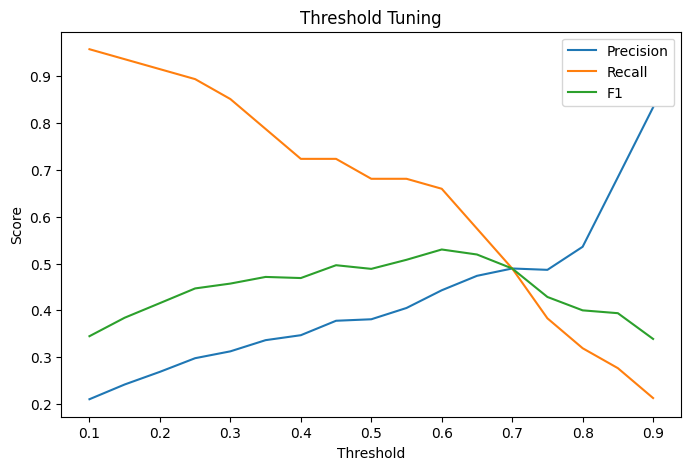

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
plt.plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
plt.plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")
plt.legend()

plt.show()

### Threshold Tuning Findings

Threshold tuning demonstrated the tradeoff between precision and recall when changing the probability cutoff used for attrition prediction.

At very low thresholds (such as 0.10):
- recall became extremely high (95.7%),
- but precision became very low (21.0%).

This means the model identified almost every employee who left, but also incorrectly flagged many employees who stayed.

As the threshold increased:
- precision gradually improved,
- while recall steadily decreased.

The best overall F1 score was achieved around the 0.60 threshold:
- Precision: 44.3%
- Recall: 66.0%
- F1 Score: 52.9%

This threshold provided the strongest balance between identifying employees at risk and limiting excessive false positives.

The threshold tuning curve clearly showed:
- lower thresholds favour recall,
- higher thresholds favour precision.

From an HR perspective, a moderate threshold around 0.55–0.60 may provide the most practical operational balance because:
- enough at-risk employees are identified,
- while false alarm rates remain manageable for HR teams.

This demonstrates that probability thresholds should be selected based on business objectives rather than relying automatically on the default 0.50 cutoff.

## 7. Precision-Recall Curve

Precision-recall curves are useful for imbalanced datasets because they focus directly on minority class performance.

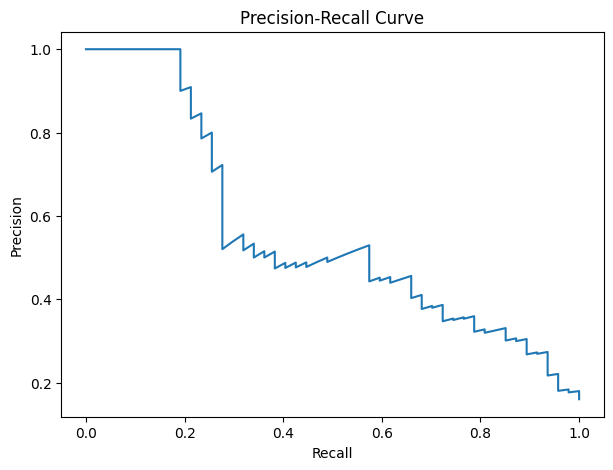

In [12]:
precision, recall, _ = precision_recall_curve(
    y_test,
    weighted_proba
)

plt.figure(figsize=(7, 5))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.show()

### Precision-Recall Curve Findings

The Precision-Recall curve highlights the tradeoff between identifying employees who may leave (recall) and avoiding excessive false alarms (precision).

The curve shows that:
- precision is very high at extremely low recall levels,
- but precision gradually decreases as recall increases.

This behaviour is expected in imbalanced classification problems because identifying more attrition cases usually introduces additional false positives.

The curve demonstrates that:
- achieving near-perfect recall requires sacrificing precision,
- while very high precision reduces the number of employees detected as attrition risks.

The most balanced region of the curve appears around moderate recall levels, where precision remains reasonably stable before declining sharply at very high recall values.

From a business perspective:
- HR teams typically prefer higher recall because missing employees who are likely to leave can be expensive,
- however, excessively low precision may overwhelm HR with too many false alarms.

This confirms that the attrition prediction problem requires balancing business intervention capacity against retention risk exposure.

## 8. SMOTE Oversampling

SMOTE creates synthetic examples of the minority class to improve model learning.

SMOTE is applied ONLY to the training data to prevent data leakage.

In [13]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\caspe\anaconda\envs\genexa_ds\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Before SMOTE:
Attrition
0    986
1    190
Name: count, dtype: int64

After SMOTE:
Attrition
0    986
1    986
Name: count, dtype: int64


In [14]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

smote_pred = smote_model.predict(X_test)
smote_proba = smote_model.predict_proba(X_test)[:, 1]

smote_results = {
    "Accuracy": accuracy_score(y_test, smote_pred),
    "Precision": precision_score(y_test, smote_pred),
    "Recall": recall_score(y_test, smote_pred),
    "F1": f1_score(y_test, smote_pred),
    "ROC-AUC": roc_auc_score(y_test, smote_proba)
}

pd.DataFrame([smote_results])

,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.785714,0.397436,0.659574,0.496,0.812818


## SMOTE Findings

SMOTE (Synthetic Minority Oversampling Technique) was applied to address class imbalance by generating synthetic examples of employees in the minority attrition class.

Before applying SMOTE:
- Employees who stayed: 986
- Employees who left: 190

After applying SMOTE:
- Employees who stayed: 986
- Employees who left: 986

This created a perfectly balanced training dataset, allowing the model to learn attrition patterns more effectively.

After training the Logistic Regression model using SMOTE:
- Precision = 39.7%
- Recall = 66.0%
- F1 Score = 49.6%
- ROC-AUC = 0.813

Compared to the baseline model:
- recall improved substantially,
- F1 score improved,
- but precision decreased.

Compared to class weighting:
- SMOTE produced slightly lower recall,
- but achieved a slightly better F1 score,
- indicating a better balance between detecting attrition and controlling false positives.

The results suggest that SMOTE helped the model become more sensitive to attrition cases without excessively damaging overall ranking performance.

From a business perspective:
- SMOTE improves the organisation’s ability to proactively identify employees at risk of leaving,
- but HR teams must still manage increased false positive predictions carefully.

Overall, SMOTE demonstrated strong potential as a practical imbalance-handling strategy for attrition prediction.

## 9. Final Imbalance Strategy Comparison

In [15]:
comparison_df = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "Class Weighted",
        "SMOTE"
    ],
    "Precision": [
        baseline_results["Precision"],
        weighted_results["Precision"],
        smote_results["Precision"]
    ],
    "Recall": [
        baseline_results["Recall"],
        weighted_results["Recall"],
        smote_results["Recall"]
    ],
    "F1": [
        baseline_results["F1"],
        weighted_results["F1"],
        smote_results["F1"]
    ],
    "ROC-AUC": [
        baseline_results["ROC-AUC"],
        weighted_results["ROC-AUC"],
        smote_results["ROC-AUC"]
    ]
})

comparison_df

,Strategy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.666667,0.340426,0.450704,0.836851
1,Class Weighted,0.380952,0.680851,0.488550,0.826169
2,SMOTE,0.397436,0.659574,0.496000,0.812818


## Final Imbalance Strategy Comparison Findings

Three approaches were compared:
1. Baseline Logistic Regression
2. Class Weighted Logistic Regression
3. SMOTE Oversampling with Logistic Regression

### Baseline Model
- Precision: 66.7%
- Recall: 34.0%
- F1 Score: 45.1%
- ROC-AUC: 0.837

The baseline model produced the highest precision and ROC-AUC score, meaning it was conservative and generated fewer false alarms. However, it missed many employees who actually left due to its low recall.

---

### Class Weighted Model
- Precision: 38.1%
- Recall: 68.1%
- F1 Score: 48.9%
- ROC-AUC: 0.826

Class weighting significantly improved recall, allowing the model to identify far more employees at risk of attrition. However, this came with a notable reduction in precision.

This approach prioritises catching attrition cases, even if more false positives are introduced.

---

### SMOTE Model
- Precision: 39.7%
- Recall: 66.0%
- F1 Score: 49.6%
- ROC-AUC: 0.813

The SMOTE model produced the best overall F1 score, indicating the strongest balance between precision and recall.

Although its ROC-AUC was slightly lower than the baseline model, SMOTE provided a better operational balance for attrition prediction.

---

### Overall Interpretation

The comparison clearly shows that:
- baseline models favour precision,
- imbalance handling techniques favour recall,
- and SMOTE provided the best overall balance for this business problem.

Since employee attrition prediction is primarily a risk-detection problem, improving recall is often more valuable than maximising accuracy alone.

This analysis demonstrates why imbalance handling is critical in HR analytics applications involving employee attrition prediction.

## Majority Class Baseline

Before evaluating machine learning models, it is useful to establish a naive baseline model.

A majority-class baseline predicts the most common class for every employee.

Since most employees in the dataset stayed with the company, this baseline predicts:

- Attrition = 0 for all employees.

This helps determine whether the machine learning models are genuinely learning meaningful attrition patterns beyond simply exploiting class imbalance.

In [16]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Majority class baseline model
dummy_model = DummyClassifier(strategy="most_frequent")

# Train model
dummy_model.fit(X_train, y_train)

# Predictions
dummy_pred = dummy_model.predict(X_test)

# Evaluate
dummy_results = {
    "Accuracy": accuracy_score(y_test, dummy_pred),
    "Precision": precision_score(y_test, dummy_pred, zero_division=0),
    "Recall": recall_score(y_test, dummy_pred, zero_division=0),
    "F1": f1_score(y_test, dummy_pred, zero_division=0)
}

pd.DataFrame([dummy_results])

,Accuracy,Precision,Recall,F1
0,0.840136,0.0,0.0,0.0


In [18]:
# Create prediction comparison dataframe
baseline_predictions = pd.DataFrame({
    "ActualAttrition": y_test.values,
    "PredictedAttrition": dummy_pred
})

baseline_predictions.head(10)

,ActualAttrition,PredictedAttrition
0,0,0
1,0,0
2,0,0
3,0,0
4,1,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


### Majority Class Baseline Findings

The majority-class baseline achieved relatively high accuracy because most employees stayed with the company.

However:
- precision for attrition prediction was 0,
- recall for attrition prediction was 0,
- and the F1 score was 0.

This demonstrates why accuracy alone is misleading for imbalanced classification problems.

Although the baseline model appears accurate overall, it completely fails to identify employees who are likely to leave.

Compared to this naive baseline:
- the imbalance-handled models achieved substantially higher recall and F1 scores,
- demonstrating genuine predictive learning rather than simply exploiting class imbalance.

The imbalance handling strategy substantially outperformed the naive majority-class baseline.

A majority-class classifier would predict all employees as non-attrition cases, producing an F1 score of 0.00 for the positive attrition class.

After applying imbalance handling techniques such as class weighting, threshold tuning, and SMOTE, the final model achieved an F1 score of approximately 0.50 for the attrition class, representing an improvement of nearly 50 percentage points over the baseline.